# V1 Orientation Sequence Simulation and Raster

This notebook runs `SystemNESTSim` with 8 visual orientations.

Stimulus protocol:
- 8 orientations: 0°, 45°, 90°, 135°, 180°, 225°, 270°, 315°
- each orientation shown for 1 second
- 1 second blank gap between orientations

Then it plots a population activity raster across neurons.

In [1]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [2]:
# Load run config generated by run_visual_orientations_raster.py
run_data_path = "outputs/data_system_sim_0.05scale/visual_orientations_8"
run_config_path = os.path.join(run_data_path, "visual8_run_config.pkl")

with open(run_config_path, "rb") as f:
    run_config = pickle.load(f)

orientations_deg = run_config["orientations_deg"]
n_repeats = run_config["n_repeats"]
dt_ms = run_config["dt_ms"]
on_duration_ms = run_config["on_duration_ms"]
off_duration_ms = run_config["off_duration_ms"]
input_duration_ms = run_config["input_duration_ms"]
epoch_info = run_config["epoch_info"]
sample_info = run_config["sample_info"]
presim_ms = run_config["presim_ms"]
data_path = run_config["data_path"]

print("Loaded run config:", run_config_path)
print("orientations:", orientations_deg)
print("repeats:", n_repeats)
print("input_duration_ms:", input_duration_ms)

Loaded run config: outputs/data_system_sim_0.05scale/visual_orientations_8/visual8_run_config.pkl
orientations: [0, 45, 90, 135, 180, 225, 270, 315]
repeats: 10
input_duration_ms: 11200.0


In [3]:
# Analysis notebook: no simulation is run here.
# First run: python run_visual_orientations_raster.py
print("Data path:", data_path)
print("Presim (ms):", presim_ms)

Data path: /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/visual_orientations_8
Presim (ms): 1000


In [4]:
# Quick metadata preview
run_config

{'orientations_deg': [0, 45, 90, 135, 180, 225, 270, 315],
 'n_repeats': 10,
 'dt_ms': 0.1,
 'on_duration_ms': 70,
 'off_duration_ms': 70,
 'input_duration_ms': 11200.0,
 'epoch_info': [(70.0, 140.0, '0°'),
  (210.0, 280.0, '45°'),
  (350.0, 420.0, '90°'),
  (490.0, 560.0, '135°'),
  (630.0, 700.0, '180°'),
  (770.0, 840.0, '225°'),
  (910.0, 980.0, '270°'),
  (1050.0, 1120.0, '315°'),
  (1190.0, 1260.0, '0°'),
  (1330.0, 1400.0, '45°'),
  (1470.0, 1540.0, '90°'),
  (1610.0, 1680.0, '135°'),
  (1750.0, 1820.0, '180°'),
  (1890.0, 1960.0, '225°'),
  (2030.0, 2100.0, '270°'),
  (2170.0, 2240.0, '315°'),
  (2310.0, 2380.0, '0°'),
  (2450.0, 2520.0, '45°'),
  (2590.0, 2660.0, '90°'),
  (2730.0, 2800.0, '135°'),
  (2870.0, 2940.0, '180°'),
  (3010.0, 3080.0, '225°'),
  (3150.0, 3220.0, '270°'),
  (3290.0, 3360.0, '315°'),
  (3430.0, 3500.0, '0°'),
  (3570.0, 3640.0, '45°'),
  (3710.0, 3780.0, '90°'),
  (3850.0, 3920.0, '135°'),
  (3990.0, 4060.0, '180°'),
  (4130.0, 4200.0, '225°'),
  (4270

In [5]:
print("Loaded metadata for analysis.")
print("Expected samples (angles x repeats):", len(orientations_deg) * n_repeats)
print("Number of trials (orientations x repeats):", len(sample_info))

Loaded metadata for analysis.
Expected samples (angles x repeats): 80
Number of trials (orientations x repeats): 80


In [6]:
def load_spikes_robust(path, name_prefix, begin_ms, end_ms):
    spike_files = sorted(glob.glob(os.path.join(path, f"{name_prefix}-*.dat")))
    if len(spike_files) == 0:
        raise FileNotFoundError(f"No files found for prefix '{name_prefix}' in {path}")

    node_ids = np.loadtxt(os.path.join(path, "population_nodeids.dat"), dtype=int)
    if node_ids.ndim == 1:
        node_ids = node_ids[None, :]

    last_node_id = node_ids[-1, -1]
    all_times = []
    all_neurons = []

    for file_path in spike_files:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                parts = stripped.split()
                if len(parts) < 2:
                    continue
                try:
                    sender = int(float(parts[0]))
                    time_ms = float(parts[1])
                except ValueError:
                    continue

                if begin_ms <= time_ms <= end_ms:
                    neuron_idx = abs(sender - last_node_id) + 1
                    all_times.append(time_ms)
                    all_neurons.append(neuron_idx)

    return np.asarray(all_times), np.asarray(all_neurons), spike_files

# Plot window in stimulus-aligned time (ms)
raster_begin_ms = 0
raster_end_ms = input_duration_ms

# Convert to absolute simulation-time window and guard against negative start
begin_abs_ms = max(0.0, raster_begin_ms + presim_ms)
end_abs_ms = raster_end_ms + presim_ms

# Spike recorder files are now in a spike_recorder/ subdirectory
sd_dir = os.path.join(data_path, "spike_recorder")

times_all, neurons_all, spike_files = load_spikes_robust(
    sd_dir,
    "spike_recorder",
    begin_abs_ms,
    end_abs_ms,
)

# Shift to stimulus-aligned axis where 0 ms is visual stimulus onset
times_all = times_all - presim_ms

print(f"Loaded {len(times_all)} spikes from {len(spike_files)} files.")
if len(times_all) > 0:
    print(f"Spike time range (stim-aligned): {times_all.min():.1f} to {times_all.max():.1f} ms")


Loaded 92618 spikes from 32 files.
Spike time range (stim-aligned): 0.1 to 11199.9 ms


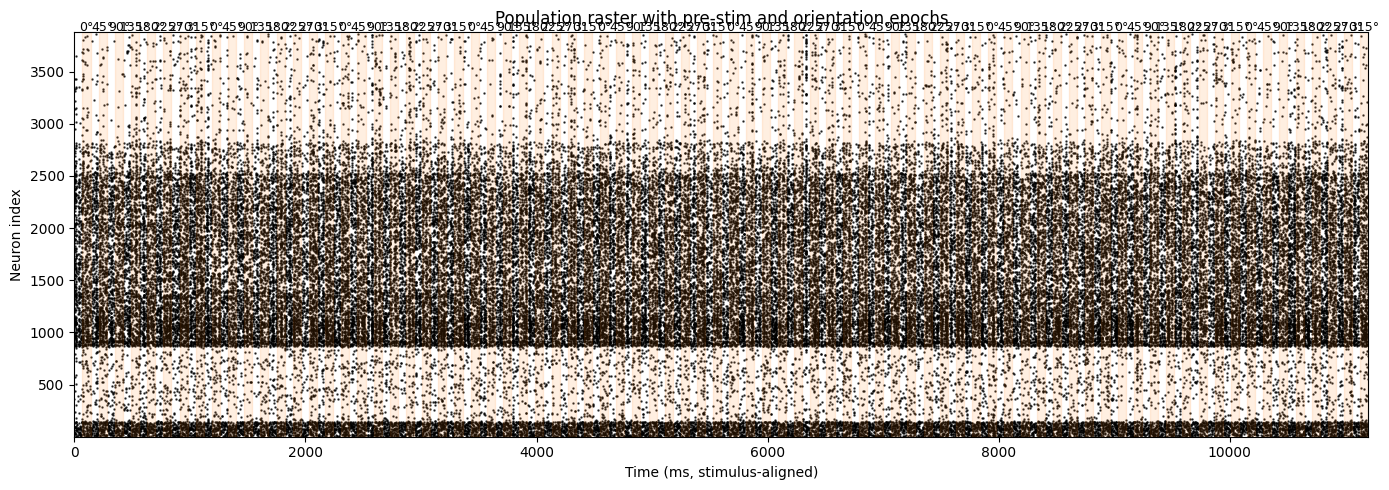

In [7]:
if len(times_all) == 0:
    print("No spikes found in selected range.")
else:
    plt.figure(figsize=(14, 5))
    plt.scatter(times_all, neurons_all, s=0.6, c="k", alpha=0.7)

    ymin, ymax = np.min(neurons_all), np.max(neurons_all)

    # Mark pre-stim period
    if raster_begin_ms < 0:
        plt.axvspan(raster_begin_ms, 0, color="tab:blue", alpha=0.08)
        plt.text(
            0.5 * raster_begin_ms,
            ymax + 5,
            "pre-stim",
            ha="center",
            va="bottom",
            fontsize=9,
            color="tab:blue",
        )

    # Mark stimulus-on orientation epochs
    for start_ms, end_ms, label in epoch_info:
        plt.axvspan(start_ms, end_ms, color="tab:orange", alpha=0.12)
        plt.text(
            0.5 * (start_ms + end_ms),
            ymax + 5,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.xlim(raster_begin_ms, raster_end_ms)
    plt.ylim(ymin, ymax + 20)
    plt.xlabel("Time (ms, stimulus-aligned)")
    plt.ylabel("Neuron index")
    plt.title("Population raster with pre-stim and orientation epochs")
    plt.tight_layout()
    plt.show()

/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_37701/3260341913.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = plt.cm.get_cmap("tab10", len(unique_angles))


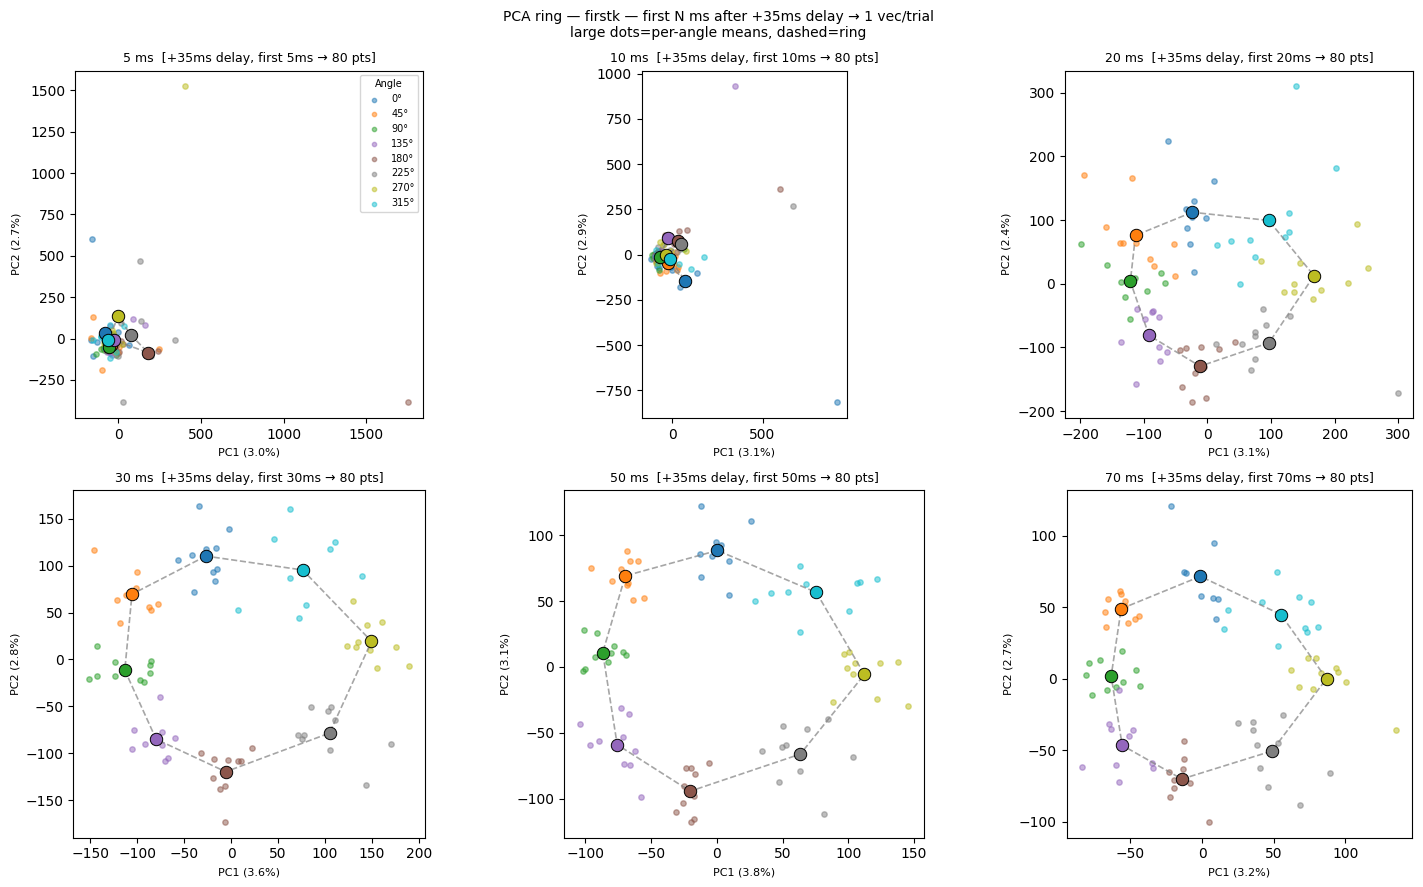

In [55]:
if len(times_all) == 0:
    print("No spikes available for PCA.")
else:
    # MODE options:
    #   "point_window"   — each non-overlapping window is a distinct point (5ms → 14× more points than 70ms)
    #   "sliding_window" — all windows averaged → 1 vector per trial
    #   "firstk"         — just the first trial_portion ms after stimulus onset → 1 vector per trial
    MODE               = "firstk"
    FIRST_ONLY_DELAY_MS = 35.0   # ms offset from stimulus onset before sampling (firstk only)
    EPOCH_MS           = 70.0    # total epoch length (used by point_window and sliding_window)

    n_neurons     = int(np.max(neurons_all))
    unique_angles = sorted(np.unique([s[2] for s in sample_info]))
    cmap          = plt.cm.get_cmap("tab10", len(unique_angles))
    trial_portions = [5, 10, 20, 30, 50, 70]

    def _epoch_vectors(start_ms, trial_portion):
        n_wins = max(1, int(EPOCH_MS / trial_portion))

        if MODE == "firstk":
            ws     = start_ms + FIRST_ONLY_DELAY_MS
            mask   = (times_all >= ws) & (times_all < ws + trial_portion)
            counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)
            return [counts / (trial_portion / 1000.0)]

        win_vecs = []
        for w in range(n_wins):
            ws   = start_ms + w * trial_portion
            mask = (times_all >= ws) & (times_all < ws + trial_portion)
            counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)
            win_vecs.append(counts / (trial_portion / 1000.0))

        if MODE == "sliding_window":
            return [np.mean(win_vecs, axis=0)]
        else:  # point_window
            return win_vecs

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for ax, trial_portion in zip(axes, trial_portions):
        n_wins = max(1, int(EPOCH_MS / trial_portion))

        sample_vectors, sample_angles = [], []
        for start_ms, end_ms, angle_deg, repeat_idx in sample_info:
            for vec in _epoch_vectors(start_ms, trial_portion):
                sample_vectors.append(vec)
                sample_angles.append(angle_deg)

        sample_vectors = np.asarray(sample_vectors)
        sample_angles  = np.asarray(sample_angles)

        pca_local  = PCA(n_components=2)
        sample_pca = pca_local.fit_transform(sample_vectors)

        for i, angle in enumerate(unique_angles):
            m = sample_angles == angle
            ax.scatter(sample_pca[m, 0], sample_pca[m, 1],
                       color=cmap(i), s=15, alpha=0.5, label=f"{int(angle)}°")

        avg_pca = np.array([sample_pca[sample_angles == a].mean(0) for a in unique_angles])
        ro = np.argsort(unique_angles)
        ax.plot(np.append(avg_pca[ro, 0], avg_pca[ro[0], 0]),
                np.append(avg_pca[ro, 1], avg_pca[ro[0], 1]),
                "--", color="grey", lw=1.2, alpha=0.7)
        for i, angle in enumerate(unique_angles):
            ax.scatter(*avg_pca[i], color=cmap(i), s=80, edgecolors="k", lw=0.7, zorder=3)

        ev = pca_local.explained_variance_ratio_
        ax.set_xlabel(f"PC1 ({ev[0]:.1%})", fontsize=8)
        ax.set_ylabel(f"PC2 ({ev[1]:.1%})", fontsize=8)
        n_pts = len(sample_vectors)
        if MODE == "point_window":
            win_note = f"{n_wins}w → {n_pts} pts"
        elif MODE == "sliding_window":
            win_note = f"avg {n_wins}w → {n_pts} pts"
        else:
            win_note = f"+{FIRST_ONLY_DELAY_MS:.0f}ms delay, first {trial_portion}ms → {n_pts} pts"
        ax.set_title(f"{trial_portion} ms  [{win_note}]", fontsize=9)
        ax.set_aspect("equal")

    axes[0].legend(title="Angle", fontsize=7, title_fontsize=7,
                   loc="upper right", markerscale=0.8)
    mode_labels = {
        "point_window":   "point_window — each non-overlapping window = distinct point",
        "sliding_window": "sliding_window — non-overlapping windows averaged → 1 vec/trial",
        "firstk":         f"firstk — first N ms after +{FIRST_ONLY_DELAY_MS:.0f}ms delay → 1 vec/trial",
    }
    plt.suptitle(f"PCA ring — {mode_labels[MODE]}\nlarge dots=per-angle means, dashed=ring",
                 fontsize=10)
    plt.tight_layout()
    plt.show()


ON periods (stimulus, 70 ms)  n=80  →  PC1–3: [0.0552 0.0425 0.0182]  cumulative: 0.116  |  90%: PC67,  95%: PC73
OFF periods (rest, 70 ms)  n=79  →  PC1–3: [0.0209 0.0196 0.0191]  cumulative: 0.060  |  90%: PC67,  95%: PC72


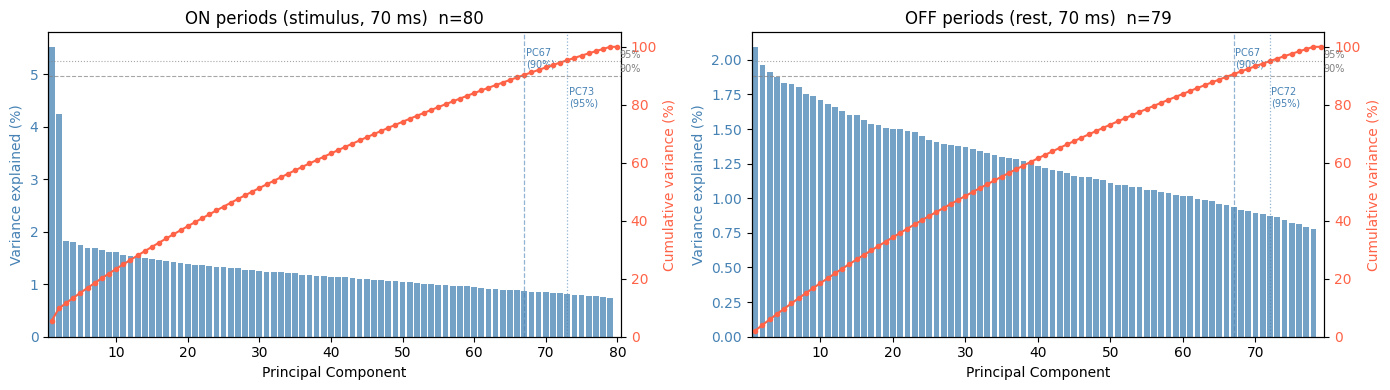

In [40]:
# ── Scree plots: ON-period vs OFF-period PCA ─────────────────────────────────
# on_duration_ms = off_duration_ms = 70 ms, so each period is exactly one window.
# ON  windows: [start_ms, end_ms] from sample_info
# OFF windows: gaps between consecutive trials [end_ms[i], start_ms[i+1]]
if len(times_all) == 0:
    print("No spikes available.")
else:
    n_neurons = int(np.max(neurons_all))
    duration_s = on_duration_ms / 1000.0

    def window_rate_vec(t_start, t_end):
        mask = (times_all >= t_start) & (times_all < t_end)
        counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)
        return counts / ((t_end - t_start) / 1000.0)

    # ON vectors
    on_vecs = np.array([window_rate_vec(s, e) for s, e, *_ in sample_info])

    # OFF vectors: gaps between consecutive trials
    sorted_info = sorted(sample_info, key=lambda x: x[0])
    off_vecs = np.array([
        window_rate_vec(sorted_info[i][1], sorted_info[i + 1][0])
        for i in range(len(sorted_info) - 1)
        if sorted_info[i + 1][0] - sorted_info[i][1] > 0
    ])

    def scree_data(vecs):
        n = min(vecs.shape[0], vecs.shape[1])
        pca_s = PCA(n_components=n).fit(vecs)
        evr  = pca_s.explained_variance_ratio_
        cumr = np.cumsum(evr)
        return evr, cumr, n

    evr_on,  cumr_on,  n_on  = scree_data(on_vecs)
    evr_off, cumr_off, n_off = scree_data(off_vecs)

    def draw_scree(ax1, evr, cumr, n_comp, title):
        ax2 = ax1.twinx()
        ax1.bar(np.arange(1, n_comp + 1), evr * 100, color="steelblue", alpha=0.75)
        ax2.plot(np.arange(1, n_comp + 1), cumr * 100,
                 color="tomato", marker="o", markersize=3, linewidth=1.5)
        for thresh, ls in [(90, "--"), (95, ":")]:
            ax2.axhline(thresh, color="gray", linestyle=ls, linewidth=0.8, alpha=0.7)
            ax2.text(n_comp + 0.3, thresh + 0.5, f"{thresh}%", color="gray", fontsize=7, va="bottom")
        ax1.set_xlabel("Principal Component")
        ax1.set_ylabel("Variance explained (%)", color="steelblue")
        ax2.set_ylabel("Cumulative variance (%)", color="tomato")
        ax1.set_xlim(0.5, n_comp + 0.5)
        ax1.set_ylim(0)
        ax2.set_ylim(0, 105)
        ax1.tick_params(axis="y", labelcolor="steelblue")
        ax2.tick_params(axis="y", labelcolor="tomato")
        ax1.set_title(title)
        for thresh, ls in [(0.90, "--"), (0.95, ":")]:
            nx = int(np.searchsorted(cumr, thresh)) + 1
            ax1.axvline(nx, color="steelblue", linestyle=ls, linewidth=0.9, alpha=0.6)
            ax1.text(nx + 0.2, ax1.get_ylim()[1] * (0.95 if thresh == 0.90 else 0.82),
                     f"PC{nx}\n({int(thresh*100)}%)", fontsize=7, color="steelblue", va="top")
        n90 = int(np.searchsorted(cumr, 0.90)) + 1
        n95 = int(np.searchsorted(cumr, 0.95)) + 1
        print(f"{title}  →  PC1–3: {evr[:3].round(4)}  cumulative: {cumr[2]:.3f}  |  90%: PC{n90},  95%: PC{n95}")

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4))
    draw_scree(axL, evr_on,  cumr_on,  n_on,
               f"ON periods (stimulus, 70 ms)  n={on_vecs.shape[0]}")
    draw_scree(axR, evr_off, cumr_off, n_off,
               f"OFF periods (rest, 70 ms)  n={off_vecs.shape[0]}")
    plt.tight_layout()
    plt.show()


In [32]:

# Cluster centers: mean PC coordinates per orientation, and their neural-space inverse
unique_angles = sorted(np.unique(sample_angles))

cluster_centers_pc = []
cluster_centers_neural = []

print(f"{'Angle':>8}  {'PC1':>10}  {'PC2':>10}  {'||neural||':>12}  {'top-3 neurons (rate Hz)':}")
print("-" * 72)

for angle in unique_angles:
    mask = sample_angles == angle
    center_pc = sample_pca[mask].mean(axis=0)           # (n_components,)
    center_neural = pca.inverse_transform(center_pc)    # (n_neurons,)

    cluster_centers_pc.append(center_pc)
    cluster_centers_neural.append(center_neural)

    top3 = np.argsort(center_neural)[-3:][::-1]
    top3_str = ", ".join(f"n{i}={center_neural[i]:.1f}" for i in top3)
    print(f"{angle:>7}°  {center_pc[0]:>10.3f}  {center_pc[1]:>10.3f}  "
          f"{np.linalg.norm(center_neural):>12.2f}  {top3_str}")

cluster_centers_pc = np.array(cluster_centers_pc)       # (8, 2)
cluster_centers_neural = np.array(cluster_centers_neural)  # (8, n_neurons)

print(f"\ncluster_centers_pc.shape    = {cluster_centers_pc.shape}")
print(f"cluster_centers_neural.shape = {cluster_centers_neural.shape}")


   Angle         PC1         PC2    ||neural||  top-3 neurons (rate Hz)
------------------------------------------------------------------------


ValueError: Expected 2D array, got 1D array instead:
array=[-11.82517765  91.30581538].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [19]:
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)

saved_results = {}
for i, angle in enumerate(unique_angles):
    center_pc = cluster_centers_pc[i]
    center_neural = cluster_centers_neural[i]

    print(f"\nAngle {angle}°:")
    print(f"  PC coordinates: {center_pc}")
    print(f"  Neural-space vector norm: {np.linalg.norm(center_neural):.2f}")

    saved_results[int(angle)] = {
        "pc_coordinates": center_pc,
        "neural_vector_norm": np.linalg.norm(center_neural),
        "top_3_neurons": np.argsort(center_neural)[-3:][::-1],
        "full_neural_vector": center_neural,
    }

json_path = os.path.join(run_data_path, "cluster_centers_analysis.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(saved_results, f, indent=2, cls=NumpyEncoder)
print(f"\nSaved cluster center analysis results to {json_path}")



Angle 0°:
  PC coordinates: [-11.82496448  91.29409791]
  Neural-space vector norm: 222.51

Angle 45°:
  PC coordinates: [-75.86585875  67.77578488]
  Neural-space vector norm: 217.53

Angle 90°:
  PC coordinates: [-95.63842082   4.07682712]
  Neural-space vector norm: 211.58

Angle 135°:
  PC coordinates: [-73.81057613 -71.24281796]
  Neural-space vector norm: 217.60

Angle 180°:
  PC coordinates: [ -8.39899238 -96.63918366]
  Neural-space vector norm: 224.25

Angle 225°:
  PC coordinates: [ 74.46093587 -62.43895854]
  Neural-space vector norm: 235.77

Angle 270°:
  PC coordinates: [114.34884548   6.79199299]
  Neural-space vector norm: 248.81

Angle 315°:
  PC coordinates: [76.72903121 60.38225727]
  Neural-space vector norm: 236.77

Saved cluster center analysis results to outputs/data_system_sim_0.05scale/visual_orientations_8/cluster_centers_analysis.json


PC1–3 variance: [0.0552 0.0425 0.0182]  (cumulative: 0.116)
Components needed – 90%: 67,  95%: 73


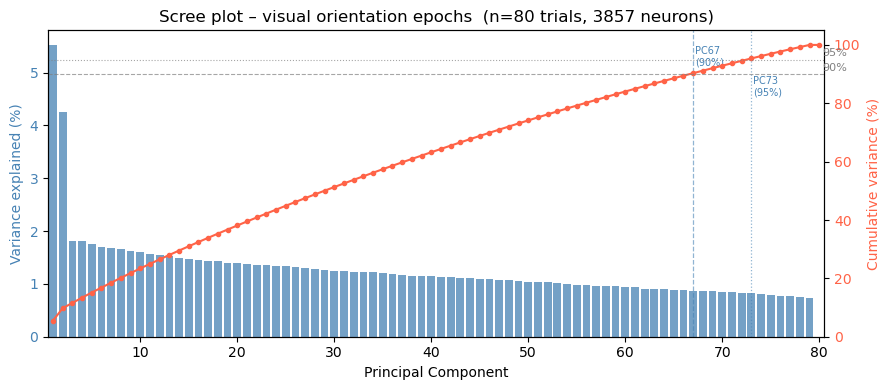

In [20]:
# ── Scree plot: variance explained by PCA on epoch activity vectors ─────────
if len(times_all) == 0:
    print("No spikes available for scree plot.")
else:
    N_COMPONENTS = min(sample_vectors.shape[0], sample_vectors.shape[1])
    pca_full = PCA(n_components=N_COMPONENTS)
    pca_full.fit(sample_vectors)

    evr  = pca_full.explained_variance_ratio_
    cumr = np.cumsum(evr)

    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax2 = ax1.twinx()

    ax1.bar(np.arange(1, N_COMPONENTS + 1), evr * 100,
            color="steelblue", alpha=0.75)
    ax2.plot(np.arange(1, N_COMPONENTS + 1), cumr * 100,
             color="tomato", marker="o", markersize=3, linewidth=1.5)
    ax2.axhline(90, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax2.axhline(95, color="gray", linestyle=":",  linewidth=0.8, alpha=0.7)
    ax2.text(N_COMPONENTS + 0.3, 90.5, "90%", color="gray", fontsize=8, va="bottom")
    ax2.text(N_COMPONENTS + 0.3, 95.5, "95%", color="gray", fontsize=8, va="bottom")

    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Variance explained (%)", color="steelblue")
    ax2.set_ylabel("Cumulative variance (%)", color="tomato")
    ax1.set_xlim(0.5, N_COMPONENTS + 0.5)
    ax1.set_ylim(0)
    ax2.set_ylim(0, 105)
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax1.set_title(
        f"Scree plot – visual orientation epochs  "
        f"(n={sample_vectors.shape[0]} trials, {sample_vectors.shape[1]} neurons)"
    )

    n90 = int(np.searchsorted(cumr, 0.90)) + 1
    n95 = int(np.searchsorted(cumr, 0.95)) + 1
    ax1.axvline(n90, color="steelblue", linestyle="--", linewidth=0.9, alpha=0.6)
    ax1.axvline(n95, color="steelblue", linestyle=":",  linewidth=0.9, alpha=0.6)
    ylim_top = ax1.get_ylim()[1]
    ax1.text(n90 + 0.2, ylim_top * 0.95, f"PC{n90}\n(90%)", fontsize=7, color="steelblue", va="top")
    ax1.text(n95 + 0.2, ylim_top * 0.85, f"PC{n95}\n(95%)", fontsize=7, color="steelblue", va="top")

    print(f"PC1–3 variance: {evr[:3].round(4)}  (cumulative: {cumr[2]:.3f})")
    print(f"Components needed – 90%: {n90},  95%: {n95}")
    plt.tight_layout()
    plt.show()


ON periods (stimulus, 70 ms)  n=80  →  PC1–3: [0.0552 0.0425 0.0182]  cumulative: 0.116  |  90%: PC67,  95%: PC73
OFF periods (rest, 70 ms)  n=79  →  PC1–3: [0.0209 0.0196 0.0191]  cumulative: 0.060  |  90%: PC67,  95%: PC72


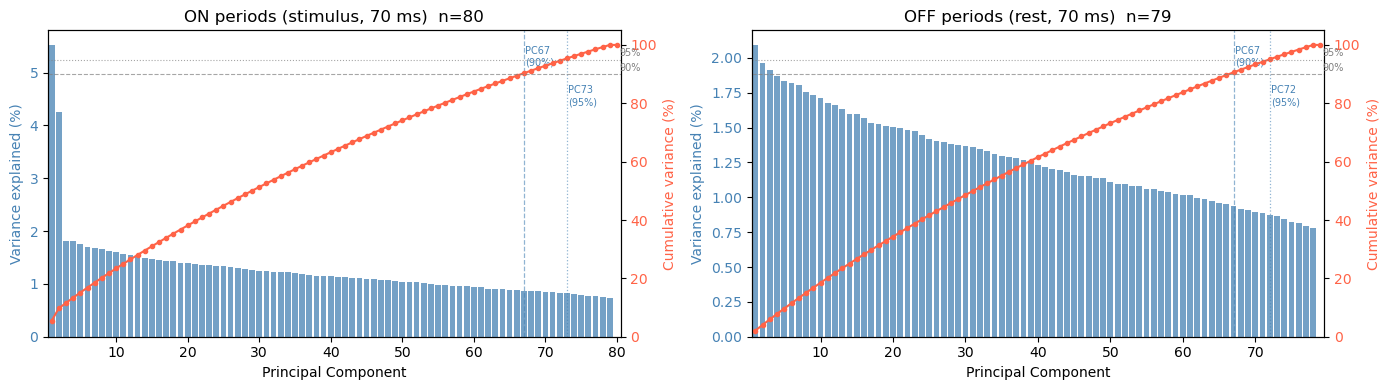

In [21]:
# ── Scree plots: ON-period vs OFF-period PCA ─────────────────────────────────
# on_duration_ms = off_duration_ms = 70 ms, so each period is exactly one window.
# ON  windows: [start_ms, end_ms] from sample_info
# OFF windows: gaps between consecutive trials [end_ms[i], start_ms[i+1]]
if len(times_all) == 0:
    print("No spikes available.")
else:
    n_neurons = int(np.max(neurons_all))
    duration_s = on_duration_ms / 1000.0

    def window_rate_vec(t_start, t_end):
        mask = (times_all >= t_start) & (times_all < t_end)
        counts = np.bincount(neurons_all[mask].astype(int) - 1, minlength=n_neurons)
        return counts / ((t_end - t_start) / 1000.0)

    # ON vectors
    on_vecs = np.array([window_rate_vec(s, e) for s, e, *_ in sample_info])

    # OFF vectors: gaps between consecutive trials
    sorted_info = sorted(sample_info, key=lambda x: x[0])
    off_vecs = np.array([
        window_rate_vec(sorted_info[i][1], sorted_info[i + 1][0])
        for i in range(len(sorted_info) - 1)
        if sorted_info[i + 1][0] - sorted_info[i][1] > 0
    ])

    def scree_data(vecs):
        n = min(vecs.shape[0], vecs.shape[1])
        pca_s = PCA(n_components=n).fit(vecs)
        evr  = pca_s.explained_variance_ratio_
        cumr = np.cumsum(evr)
        return evr, cumr, n

    evr_on,  cumr_on,  n_on  = scree_data(on_vecs)
    evr_off, cumr_off, n_off = scree_data(off_vecs)

    def draw_scree(ax1, evr, cumr, n_comp, title):
        ax2 = ax1.twinx()
        ax1.bar(np.arange(1, n_comp + 1), evr * 100, color="steelblue", alpha=0.75)
        ax2.plot(np.arange(1, n_comp + 1), cumr * 100,
                 color="tomato", marker="o", markersize=3, linewidth=1.5)
        for thresh, ls in [(90, "--"), (95, ":")]:
            ax2.axhline(thresh, color="gray", linestyle=ls, linewidth=0.8, alpha=0.7)
            ax2.text(n_comp + 0.3, thresh + 0.5, f"{thresh}%", color="gray", fontsize=7, va="bottom")
        ax1.set_xlabel("Principal Component")
        ax1.set_ylabel("Variance explained (%)", color="steelblue")
        ax2.set_ylabel("Cumulative variance (%)", color="tomato")
        ax1.set_xlim(0.5, n_comp + 0.5)
        ax1.set_ylim(0)
        ax2.set_ylim(0, 105)
        ax1.tick_params(axis="y", labelcolor="steelblue")
        ax2.tick_params(axis="y", labelcolor="tomato")
        ax1.set_title(title)
        for thresh, ls in [(0.90, "--"), (0.95, ":")]:
            nx = int(np.searchsorted(cumr, thresh)) + 1
            ax1.axvline(nx, color="steelblue", linestyle=ls, linewidth=0.9, alpha=0.6)
            ax1.text(nx + 0.2, ax1.get_ylim()[1] * (0.95 if thresh == 0.90 else 0.82),
                     f"PC{nx}\n({int(thresh*100)}%)", fontsize=7, color="steelblue", va="top")
        n90 = int(np.searchsorted(cumr, 0.90)) + 1
        n95 = int(np.searchsorted(cumr, 0.95)) + 1
        print(f"{title}  →  PC1–3: {evr[:3].round(4)}  cumulative: {cumr[2]:.3f}  |  90%: PC{n90},  95%: PC{n95}")

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4))
    draw_scree(axL, evr_on,  cumr_on,  n_on,
               f"ON periods (stimulus, 70 ms)  n={on_vecs.shape[0]}")
    draw_scree(axR, evr_off, cumr_off, n_off,
               f"OFF periods (rest, 70 ms)  n={off_vecs.shape[0]}")
    plt.tight_layout()
    plt.show()
